# Instalações e importações

In [1]:
# Instalações

%pip install pandas
%pip install matplotlib
%pip install tqdm
%pip install ipympl
%pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:

from pathlib import Path
import os
import glob
import pandas as pd
from typing import Any
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
from collections import Counter
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

# Pre processamento

In [3]:
DATA_PATH = Path().cwd() / 'data'
DATASET_PATH  = DATA_PATH / 'CSE-CIC-IDS2018' 
SAMPLE_PCT = 20                # Substitua pela porcentagem desejada (ex: 10 para 10%)
RANDOM_SEED = 1
SKIP_IF_SAMPLE_ALREADY_EXSISTS = True
SKIP_IF_PREPROCESSED_EXISTS = True

SAMPLES_PATH = DATASET_PATH / 'samples'
PROCESSEDS_PATH = DATASET_PATH / 'processed'
os.makedirs(SAMPLES_PATH, exist_ok=True)
os.makedirs(PROCESSEDS_PATH, exist_ok=True)

processed_file_path = PROCESSEDS_PATH / f'data-{SAMPLE_PCT}_pct.csv'
if processed_file_path.is_file():
    df = pd.read_csv(processed_file_path)

### Cria samples dos arquivos originais que são muito grandes

In [4]:
if (not processed_file_path.is_file() or not SKIP_IF_PREPROCESSED_EXISTS):

    csv_files_paths = glob.glob(os.path.join(DATASET_PATH, f'*.csv'))

    if not csv_files_paths:
        print(f"Nenhum arquivo .csv encontrado no diretório: {DATASET_PATH}")
    else:
        print(f"Encontrados {len(csv_files_paths)} arquivos. Iniciando amostragem de {SAMPLE_PCT}%...\n")
        
        for file_path in csv_files_paths:
            filename = os.path.basename(file_path)
            filename_no_ext, ext = os.path.splitext(filename)
            
            new_filename = f"{filename_no_ext}-{SAMPLE_PCT}_pct{ext}"
            save_path = SAMPLES_PATH / new_filename
            
            if (save_path.is_file() and SKIP_IF_SAMPLE_ALREADY_EXSISTS):
                print(f"⏩ Arquivo {new_filename} já existente, processamento ignorado!")
                continue

            try:
                df = pd.read_csv(file_path)
                sample_df = df.sample(frac=SAMPLE_PCT / 100.0, random_state=RANDOM_SEED)
                sample_df.to_csv(save_path, index=False)
                
                print(f"✅ Salvo: {new_filename} | Linhas originais: {len(df)} -> Amostra: {len(sample_df)}")
                
            except Exception as e:
                print(f"❌ Erro ao processar o arquivo {filename}: {e}")

        print("\nProcessamento concluído com sucesso!")
else:
    print("⏩ Célula ignorada, dataset pre-processado encontrado")

Encontrados 10 arquivos. Iniciando amostragem de 20%...

✅ Salvo: 02-14-2018-20_pct.csv | Linhas originais: 1048575 -> Amostra: 209715
✅ Salvo: 02-15-2018-20_pct.csv | Linhas originais: 1048575 -> Amostra: 209715


C:\Users\joaov\AppData\Local\Temp\ipykernel_8620\2929764875.py:22: DtypeWarning: Columns (0: Dst Port, 1: Protocol, 2: Flow Duration, 3: Tot Fwd Pkts, 4: Tot Bwd Pkts, 5: TotLen Fwd Pkts, 6: TotLen Bwd Pkts, 7: Fwd Pkt Len Max, 8: Fwd Pkt Len Min, 9: Fwd Pkt Len Mean, 10: Fwd Pkt Len Std, 11: Bwd Pkt Len Max, 12: Bwd Pkt Len Min, 13: Bwd Pkt Len Mean, 14: Bwd Pkt Len Std, 15: Flow Byts/s, 16: Flow Pkts/s, 17: Flow IAT Mean, 18: Flow IAT Std, 19: Flow IAT Max, 20: Flow IAT Min, 21: Fwd IAT Tot, 22: Fwd IAT Mean, 23: Fwd IAT Std, 24: Fwd IAT Max, 25: Fwd IAT Min, 26: Bwd IAT Tot, 27: Bwd IAT Mean, 28: Bwd IAT Std, 29: Bwd IAT Max, 30: Bwd IAT Min, 31: Fwd PSH Flags, 32: Bwd PSH Flags, 33: Fwd URG Flags, 34: Bwd URG Flags, 35: Fwd Header Len, 36: Bwd Header Len, 37: Fwd Pkts/s, 38: Bwd Pkts/s, 39: Pkt Len Min, 40: Pkt Len Max, 41: Pkt Len Mean, 42: Pkt Len Std, 43: Pkt Len Var, 44: FIN Flag Cnt, 45: SYN Flag Cnt, 46: RST Flag Cnt, 47: PSH Flag Cnt, 48: ACK Flag Cnt, 49: URG Flag Cnt, 50: 

✅ Salvo: 02-16-2018-20_pct.csv | Linhas originais: 1048575 -> Amostra: 209715
✅ Salvo: 02-20-2018-20_pct.csv | Linhas originais: 7948748 -> Amostra: 1589750
✅ Salvo: 02-21-2018-20_pct.csv | Linhas originais: 1048575 -> Amostra: 209715
✅ Salvo: 02-22-2018-20_pct.csv | Linhas originais: 1048575 -> Amostra: 209715
✅ Salvo: 02-23-2018-20_pct.csv | Linhas originais: 1048575 -> Amostra: 209715


C:\Users\joaov\AppData\Local\Temp\ipykernel_8620\2929764875.py:22: DtypeWarning: Columns (0: Dst Port, 1: Protocol, 2: Flow Duration, 3: Tot Fwd Pkts, 4: Tot Bwd Pkts, 5: TotLen Fwd Pkts, 6: TotLen Bwd Pkts, 7: Fwd Pkt Len Max, 8: Fwd Pkt Len Min, 9: Fwd Pkt Len Mean, 10: Fwd Pkt Len Std, 11: Bwd Pkt Len Max, 12: Bwd Pkt Len Min, 13: Bwd Pkt Len Mean, 14: Bwd Pkt Len Std, 15: Flow Byts/s, 16: Flow Pkts/s, 17: Flow IAT Mean, 18: Flow IAT Std, 19: Flow IAT Max, 20: Flow IAT Min, 21: Fwd IAT Tot, 22: Fwd IAT Mean, 23: Fwd IAT Std, 24: Fwd IAT Max, 25: Fwd IAT Min, 26: Bwd IAT Tot, 27: Bwd IAT Mean, 28: Bwd IAT Std, 29: Bwd IAT Max, 30: Bwd IAT Min, 31: Fwd PSH Flags, 32: Bwd PSH Flags, 33: Fwd URG Flags, 34: Bwd URG Flags, 35: Fwd Header Len, 36: Bwd Header Len, 37: Fwd Pkts/s, 38: Bwd Pkts/s, 39: Pkt Len Min, 40: Pkt Len Max, 41: Pkt Len Mean, 42: Pkt Len Std, 43: Pkt Len Var, 44: FIN Flag Cnt, 45: SYN Flag Cnt, 46: RST Flag Cnt, 47: PSH Flag Cnt, 48: ACK Flag Cnt, 49: URG Flag Cnt, 50: 

✅ Salvo: 02-28-2018-20_pct.csv | Linhas originais: 613104 -> Amostra: 122621


C:\Users\joaov\AppData\Local\Temp\ipykernel_8620\2929764875.py:22: DtypeWarning: Columns (0: Dst Port, 1: Protocol, 2: Flow Duration, 3: Tot Fwd Pkts, 4: Tot Bwd Pkts, 5: TotLen Fwd Pkts, 6: TotLen Bwd Pkts, 7: Fwd Pkt Len Max, 8: Fwd Pkt Len Min, 9: Fwd Pkt Len Mean, 10: Fwd Pkt Len Std, 11: Bwd Pkt Len Max, 12: Bwd Pkt Len Min, 13: Bwd Pkt Len Mean, 14: Bwd Pkt Len Std, 15: Flow Byts/s, 16: Flow Pkts/s, 17: Flow IAT Mean, 18: Flow IAT Std, 19: Flow IAT Max, 20: Flow IAT Min, 21: Fwd IAT Tot, 22: Fwd IAT Mean, 23: Fwd IAT Std, 24: Fwd IAT Max, 25: Fwd IAT Min, 26: Bwd IAT Tot, 27: Bwd IAT Mean, 28: Bwd IAT Std, 29: Bwd IAT Max, 30: Bwd IAT Min, 31: Fwd PSH Flags, 32: Bwd PSH Flags, 33: Fwd URG Flags, 34: Bwd URG Flags, 35: Fwd Header Len, 36: Bwd Header Len, 37: Fwd Pkts/s, 38: Bwd Pkts/s, 39: Pkt Len Min, 40: Pkt Len Max, 41: Pkt Len Mean, 42: Pkt Len Std, 43: Pkt Len Var, 44: FIN Flag Cnt, 45: SYN Flag Cnt, 46: RST Flag Cnt, 47: PSH Flag Cnt, 48: ACK Flag Cnt, 49: URG Flag Cnt, 50: 

✅ Salvo: 03-01-2018-20_pct.csv | Linhas originais: 331125 -> Amostra: 66225
✅ Salvo: 03-02-2018-20_pct.csv | Linhas originais: 1048575 -> Amostra: 209715

Processamento concluído com sucesso!


### Unifica todas as amostras em um único dataframe

In [5]:
if (not processed_file_path.is_file() or not SKIP_IF_PREPROCESSED_EXISTS):
    sampled_csv_files = glob.glob(os.path.join(SAMPLES_PATH, f'*-{SAMPLE_PCT}_pct.csv'))

    # Identificando as colunas padrões de todos os arquivos
    base_columns = None
    for file in sampled_csv_files:
        # Lê apenas a primeira linha para ser ultra rápido e checar o número de colunas
        df_temp = pd.read_csv(file, nrows=0)
        if len(df_temp.columns) == 80:
            base_columns = list(df_temp.columns)
            print(f"📌 Padrão de 80 colunas encontrado e definido a partir de: {os.path.basename(file)}")
            break

    # Validação caso nenhum arquivo tenha 80 colunas
    if base_columns is None:
        raise ValueError("❌ Nenhum arquivo com exatamente 80 colunas foi encontrado para servir de base.")

    # Lê, filtra colunas e unifica os datasets
    df_list: list[pd.DataFrame] = []

    print("\nIniciando a leitura e unificação dos arquivos...")
    for file in sampled_csv_files:
        filename = os.path.basename(file)
        try:
            # Lê o arquivo completo
            df = pd.read_csv(file)
            
            # Se o arquivo tiver colunas a mais (ex: 84 colunas), filtramos apenas as 80 da base
            # Se tiver exatamente 80, ele mantém igual.
            filtered_df: pd.DataFrame = df[base_columns]
            df_list.append(filtered_df)
            print(f"   ✅ {filename} processado ({len(df.columns)} colunas -> reduzido para 80)")
            
        except KeyError:
            print(f"   ⚠️ Avisando: O arquivo {filename} não possui todas as colunas necessárias da base e foi ignorado.")
        except Exception as e:
            print(f"   ❌ Erro ao ler {filename}: {e}")

    # Consolida tudo em um único DataFrame
    df = pd.concat(df_list, ignore_index=True)

    print("\nConvertendo a coluna 'Timestamp' para formato Epoch...")

    # Remove linhas onde o valor é literalmente a palavra 'Timestamp' (cabeçalhos no meio do dado)
    df = df[df['Timestamp'] != 'Timestamp'].copy()

    # 1. Transforma o texto em um objeto de data/hora do pandas (datetime)
    df['Timestamp_dt'] = pd.to_datetime(df['Timestamp'], format='%d/%m/%Y %H:%M:%S')

    # 2. Converte o datetime para nanosegundos desde a epoch, e divide por 10**9 para virar segundos (Timestamp Unix)
    # Convertemos para 'int64' para remover as casas decimais
    df['Timestamp'] = (df['Timestamp_dt'].astype('int64') // 10**9)

    # 3. Remove a coluna temporária de datetime que criamos para o cálculo
    df = df.drop(columns=['Timestamp_dt'])

    # 4. Ordena o dataframe de forma cronológica (do mais antigo para o mais recente)
    df = df.sort_values(by='Timestamp').reset_index(drop=True)

    df.to_csv(processed_file_path, index=False)
    print(f"✨ Concluído! Dataset final gerado com {df.shape[0]} linhas e {df.shape[1]} colunas.")
else: 
    print("⏩ Célula ignorada, dataset pre-processado encontrado")
df.head(5)

📌 Padrão de 80 colunas encontrado e definido a partir de: 02-14-2018-20_pct.csv

Iniciando a leitura e unificação dos arquivos...
   ✅ 02-14-2018-20_pct.csv processado (80 colunas -> reduzido para 80)
   ✅ 02-15-2018-20_pct.csv processado (80 colunas -> reduzido para 80)
   ✅ 02-16-2018-20_pct.csv processado (80 colunas -> reduzido para 80)
   ✅ 02-20-2018-20_pct.csv processado (84 colunas -> reduzido para 80)
   ✅ 02-21-2018-20_pct.csv processado (80 colunas -> reduzido para 80)
   ✅ 02-22-2018-20_pct.csv processado (80 colunas -> reduzido para 80)
   ✅ 02-23-2018-20_pct.csv processado (80 colunas -> reduzido para 80)


C:\Users\joaov\AppData\Local\Temp\ipykernel_8620\2349533054.py:26: DtypeWarning: Columns (0: Dst Port, 1: Protocol, 2: Flow Duration, 3: Tot Fwd Pkts, 4: Tot Bwd Pkts, 5: TotLen Fwd Pkts, 6: TotLen Bwd Pkts, 7: Fwd Pkt Len Max, 8: Fwd Pkt Len Min, 9: Fwd Pkt Len Mean, 10: Fwd Pkt Len Std, 11: Bwd Pkt Len Max, 12: Bwd Pkt Len Min, 13: Bwd Pkt Len Mean, 14: Bwd Pkt Len Std, 15: Flow Byts/s, 16: Flow Pkts/s, 17: Flow IAT Mean, 18: Flow IAT Std, 19: Flow IAT Max, 20: Flow IAT Min, 21: Fwd IAT Tot, 22: Fwd IAT Mean, 23: Fwd IAT Std, 24: Fwd IAT Max, 25: Fwd IAT Min, 26: Bwd IAT Tot, 27: Bwd IAT Mean, 28: Bwd IAT Std, 29: Bwd IAT Max, 30: Bwd IAT Min, 31: Fwd PSH Flags, 32: Bwd PSH Flags, 33: Fwd URG Flags, 34: Bwd URG Flags, 35: Fwd Header Len, 36: Bwd Header Len, 37: Fwd Pkts/s, 38: Bwd Pkts/s, 39: Pkt Len Min, 40: Pkt Len Max, 41: Pkt Len Mean, 42: Pkt Len Std, 43: Pkt Len Var, 44: FIN Flag Cnt, 45: SYN Flag Cnt, 46: RST Flag Cnt, 47: PSH Flag Cnt, 48: ACK Flag Cnt, 49: URG Flag Cnt, 50: 

   ✅ 02-28-2018-20_pct.csv processado (80 colunas -> reduzido para 80)
   ✅ 03-01-2018-20_pct.csv processado (80 colunas -> reduzido para 80)
   ✅ 03-02-2018-20_pct.csv processado (80 colunas -> reduzido para 80)

Convertendo a coluna 'Timestamp' para formato Epoch...
✨ Concluído! Dataset final gerado com 3246592 linhas e 80 colunas.


,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,0,788,-188505000000,9,0,0,0,0,0,...,0,0.0,0.0,0,0,197474750000.0,141251680160.803986,324807000000,21756000000,Benign
1,0,0,954,-699056000000,38,0,0,0,0,0,...,0,0.0,0.0,0,0,259393421052.631989,176008086248.683014,606052000000,51960000000,Benign
2,0,0,976,-919011000000,81,0,0,0,0,0,...,0,0.0,0.0,0,0,284112452380.952026,193152417061.481995,754847000000,12603000000,Benign
3,53,17,1518570,272,1,1,42,58,42,42,...,8,0.0,0.0,0,0,0.0,0.0,0,0,Benign
4,51001,6,1518570,76,3,1,31,0,31,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign


#### Limpeza dos dados

In [6]:
before_lines = df.shape[0]
df = df.dropna()
after_lines = df.shape[0]
print(f"🗑️ Linhas com valores nulos removidas: {before_lines - after_lines}")

before_cols = df.shape[1]
df = df.loc[:, df.nunique() > 1]
after_cols = df.shape[1]

print(f"🗑️ Colunas constantes removidas: {before_cols - after_cols}")

print(f"\n✨ Limpeza concluída! Dataset atualizado com {df.shape[0]} linhas e {df.shape[1]} colunas.")

df.head(5)

🗑️ Linhas com valores nulos removidas: 11911
🗑️ Colunas constantes removidas: 0

✨ Limpeza concluída! Dataset atualizado com 3234681 linhas e 80 colunas.


,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,0,788,-188505000000,9,0,0,0,0,0,...,0,0.0,0.0,0,0,197474750000.0,141251680160.803986,324807000000,21756000000,Benign
1,0,0,954,-699056000000,38,0,0,0,0,0,...,0,0.0,0.0,0,0,259393421052.631989,176008086248.683014,606052000000,51960000000,Benign
2,0,0,976,-919011000000,81,0,0,0,0,0,...,0,0.0,0.0,0,0,284112452380.952026,193152417061.481995,754847000000,12603000000,Benign
3,53,17,1518570,272,1,1,42,58,42,42,...,8,0.0,0.0,0,0,0.0,0.0,0,0,Benign
4,51001,6,1518570,76,3,1,31,0,31,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign


In [7]:
numerical_cols = df.select_dtypes(include='number').columns.tolist()
categorical_cols = df.select_dtypes(exclude='number').columns.tolist()

print(f"📊 COLUNAS NUMÉRICAS ({len(numerical_cols)} no total):")
if numerical_cols:
    print(', '.join(numerical_cols))
else:
    print("Nenhuma coluna numérica encontrada.")

print("\n" + "-"*80 + "\n")

print(f"🔤 COLUNAS CATEGÓRICAS / TEXTUAIS ({len(categorical_cols)} no total):")
if categorical_cols:
    print(', '.join(categorical_cols))
else:
    print("Nenhuma coluna categórica ou textual encontrada.")

📊 COLUNAS NUMÉRICAS (1 no total):
Timestamp

--------------------------------------------------------------------------------

🔤 COLUNAS CATEGÓRICAS / TEXTUAIS (79 no total):
Dst Port, Protocol, Flow Duration, Tot Fwd Pkts, Tot Bwd Pkts, TotLen Fwd Pkts, TotLen Bwd Pkts, Fwd Pkt Len Max, Fwd Pkt Len Min, Fwd Pkt Len Mean, Fwd Pkt Len Std, Bwd Pkt Len Max, Bwd Pkt Len Min, Bwd Pkt Len Mean, Bwd Pkt Len Std, Flow Byts/s, Flow Pkts/s, Flow IAT Mean, Flow IAT Std, Flow IAT Max, Flow IAT Min, Fwd IAT Tot, Fwd IAT Mean, Fwd IAT Std, Fwd IAT Max, Fwd IAT Min, Bwd IAT Tot, Bwd IAT Mean, Bwd IAT Std, Bwd IAT Max, Bwd IAT Min, Fwd PSH Flags, Bwd PSH Flags, Fwd URG Flags, Bwd URG Flags, Fwd Header Len, Bwd Header Len, Fwd Pkts/s, Bwd Pkts/s, Pkt Len Min, Pkt Len Max, Pkt Len Mean, Pkt Len Std, Pkt Len Var, FIN Flag Cnt, SYN Flag Cnt, RST Flag Cnt, PSH Flag Cnt, ACK Flag Cnt, URG Flag Cnt, CWE Flag Count, ECE Flag Cnt, Down/Up Ratio, Pkt Size Avg, Fwd Seg Size Avg, Bwd Seg Size Avg, Fwd Byts/b Avg

### Correção de Tipos: Convertendo Falsas Numéricas em Categóricas

In [8]:
print("Corrigindo os tipos de dados das colunas...\n")

# Lista das colunas que o Pandas acha que são números, mas na verdade são categorias nominais
false_numerical_cols = ['Dst Port', 'Protocol']

# Filtramos apenas as que realmente estão no dataframe (caso alguma tenha sido removida nas etapas de limpeza)
cols_to_convert = [col for col in false_numerical_cols if col in df.columns]

if cols_to_convert:
    for col in cols_to_convert:
        df[col] = df[col].astype('category')
        print(f"🔄 Coluna '{col}' convertida com sucesso para o tipo 'category'.")
else:
    print("Nenhuma das colunas falsas numéricas foi encontrada no DataFrame atual.")

# Exibe o tipo de dado atualizado apenas das colunas que modificamos, além do nosso Timestamp
check_cols = cols_to_convert + (['Timestamp'] if 'Timestamp' in df.columns else [])
print("\nTipos de dados atualizados para conferência:")
print(df[check_cols].dtypes)

Corrigindo os tipos de dados das colunas...

🔄 Coluna 'Dst Port' convertida com sucesso para o tipo 'category'.
🔄 Coluna 'Protocol' convertida com sucesso para o tipo 'category'.

Tipos de dados atualizados para conferência:
Dst Port     category
Protocol     category
Timestamp       int64
dtype: object


# AVALIANDO MODELOS

In [9]:
def avaliar_modelo(y_true, y_pred, nome_modelo):
    # Garante que as labels estejam na mesma ordem na matriz
    labels = sorted(list(set(y_true) | set(y_pred)))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    
    # Cálculos das métricas (Média Macro para lidar com multiclase)
    acc = (np.array(y_pred) == np.array(y_true)).mean() * 100
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0) * 100
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0) * 100
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0) * 100
    
    # O scikit-learn não tem Especificidade nativa para multiclasse, então calculamos na mão via Matriz
    specificities = []
    for i in range(len(labels)):
        tn = np.sum(cm) - np.sum(cm[i, :]) - np.sum(cm[:, i]) + cm[i, i]
        fp = np.sum(cm[:, i]) - cm[i, i]
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        specificities.append(spec)
    spec_macro = np.mean(specificities) * 100
    
    # Print Padronizado
    print("\n" + "="*65)
    print(f"🔹 AVALIAÇÃO DE DESEMPENHO: {nome_modelo}")
    print("="*65)
    print(f"Acurácia:       {acc:.4f}%")
    print(f"Precisão:       {prec:.4f}%")
    print(f"Revocação:      {rec:.4f}%")
    print(f"Especificidade: {spec_macro:.4f}%")
    print(f"F1-Score:       {f1:.4f}%")
    print("-" * 65)
    print("MATRIZ DE CONFUSÃO:")
    cm_df = pd.DataFrame(cm, index=[f"Real: {l}" for l in labels], columns=[f"Prev: {l}" for l in labels])
    print(cm_df.to_string())
    print("="*65 + "\n")

# Algoritmo Bayesiano

In [10]:
work_columns = ['Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'Label']
work_df = df[work_columns]
knowledge_df = work_df.sample(frac=0.999, random_state=RANDOM_SEED)
test_df = work_df.drop(knowledge_df.index)
possible_labels = work_df['Label'].unique()

with_exact_correspondence = 0

# Listas para guardar o gabarito e a previsão apenas de quem teve correspondência
y_true_list = []
y_pred_list = []

for i,item in tqdm(test_df.iterrows(), total=test_df.shape[0], desc="Processando linhas"):
    equal_df = knowledge_df[(knowledge_df['Dst Port'] == item['Dst Port']) & 
                            (knowledge_df['Protocol'] == item['Protocol']) &
                            (knowledge_df['Flow Duration'] == item['Flow Duration'])&
                            (knowledge_df['Tot Fwd Pkts'] == item['Tot Fwd Pkts']) &
                            (knowledge_df['Tot Bwd Pkts'] == item['Tot Bwd Pkts'])]
    
    if (equal_df.shape[0] == 0):
        continue
        
    with_exact_correspondence += 1

    greater_ratio = (-1, '')
    for possible_label in possible_labels:
        with_label_df = equal_df[equal_df['Label'] == possible_label]
        with_label_ratio = with_label_df.shape[0]/equal_df.shape[0]

        if (with_label_ratio > greater_ratio[0]):
            greater_ratio = (with_label_ratio, possible_label)

    # Coletando dados para a avaliação
    if greater_ratio[1] != '':
        y_true_list.append(item['Label'])
        y_pred_list.append(greater_ratio[1])

print(f'\nTotal de itens testados originais: {test_df.shape[0]}')
print(f'Com correspondência exata para inferência: {with_exact_correspondence} | {with_exact_correspondence / test_df.shape[0] * 100:.4f}%')

# Chama a nossa função padronizada
if len(y_true_list) > 0:
    avaliar_modelo(y_true_list, y_pred_list, "Bayesiano Simples (Correspondência Exata)")
else:
    print("Nenhuma correspondência exata encontrada para gerar métricas.")

Processando linhas: 100%|██████████| 3235/3235 [55:44<00:00,  1.03s/it]


Total de itens testados originais: 3235
Com correspondência exata para inferência: 1459 | 45.1005%

🔹 AVALIAÇÃO DE DESEMPENHO: Bayesiano Simples (Correspondência Exata)
Acurácia:       92.3235%
Precisão:       71.3681%
Revocação:      72.1114%
Especificidade: 98.4825%
F1-Score:       70.8271%
-----------------------------------------------------------------
MATRIZ DE CONFUSÃO:
                                Prev: Benign  Prev: Bot  Prev: DDOS attack-HOIC  Prev: DDoS attacks-LOIC-HTTP  Prev: DoS attacks-Hulk  Prev: DoS attacks-SlowHTTPTest  Prev: FTP-BruteForce  Prev: Infilteration  Prev: SSH-Bruteforce
Real: Benign                            1105          0                      10                             0                       2                               0                     0                    0                     0
Real: Bot                                  0         51                       0                             0                       0                        

## Algoritmo Naive Bayes

In [11]:
features = ['Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts']
target = 'Label'



work_df = df[features + [target]]

work_df.loc[(work_df[target] == 'DDOS attack-LOIC-UDP') |
            (work_df[target] == 'DoS attacks-Slowloris') |
            (work_df[target] == 'DoS attacks-GoldenEye') |
            (work_df[target] == 'DoS attacks-SlowHTTPTest') |
            (work_df[target] == 'DoS attacks-Hulk') |
            (work_df[target] == 'DDoS attacks-LOIC-HTTP') |
            (work_df[target] == 'DDOS attack-HOIC'), target] = 'DDoS'

work_df.loc[(work_df[target] == 'Brute Force -XSS') |
            (work_df[target] == 'Brute Force -Web') | 
            (work_df[target] == 'SSH-Bruteforce') | 
            (work_df[target] == 'FTP-BruteForce'), target] = 'BruteForce'

work_df.loc[(work_df[target] == 'Bot') |
            (work_df[target] == 'Infilteration') | 
            (work_df[target] == 'SQL Injection'), target] = 'Other'

possible_labels = work_df[target].unique()

# Vamos fazer undersampling no work_df para termos a mesma quantidade de dados para cada label diferente
min_class_size = work_df[target].value_counts().min()
print(work_df[target].value_counts())
work_df = work_df.groupby(target).sample(n=min_class_size, random_state=RANDOM_SEED)
work_df = work_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
print(work_df[target].value_counts())

work_df.to_csv('./work_dataframe.csv', index=False)



knowledge_df = work_df.sample(frac=0.995, random_state=RANDOM_SEED)
raw_test_df = work_df.drop(knowledge_df.index)

X_test = raw_test_df[features]
y_test = raw_test_df[target]

total_knowledge_rows = knowledge_df.shape[0]

model_predictions = []
labels_data: dict[str, dict[str, Any]] = {}

for label in possible_labels:
    label_df = knowledge_df[knowledge_df[target] == label]
    label_prob = label_df.shape[0] / total_knowledge_rows

    labels_data[label] = {
        'df': label_df,
        'prob': label_prob
    }
        
for i, item in tqdm(X_test.iterrows(), total=X_test.shape[0], desc="Processando linhas"):
    best_label = None
    max_prob = -1
    label_found_probs = {}
    
    for label in (possible_labels):
        label_df: pd.DataFrame = labels_data[label]['df']
        current_prob: float = labels_data[label]['prob']

        for col in features:
            # Conta quantas vezes o valor da feature do teste apareceu dentro deste Label
            feature_match_df = label_df[label_df[col] == item[col]]
            
            # feature_prob = (Linhas que bateram a feature) / (Total de linhas deste Label)
            feature_prob = feature_match_df.shape[0] / label_df.shape[0]
            
            # Suavização: Se não encontrou nenhuma correspondência, aplica um valor mínimo
            if feature_prob == 0:
                feature_prob = 1e-6
                
            current_prob *= feature_prob
            
        label_found_probs[label] = current_prob
        if current_prob > max_prob:
            max_prob = current_prob
            best_label = label
    
    model_predictions.append((best_label, label_found_probs))

# O list() foi adicionado para garantir que o Pandas consuma o map() corretamente
results_df = pd.DataFrame({
    'Model_Prediction': list(map(lambda x: x[0], model_predictions)),
    'Model_Prediction_probs': list(map(lambda x: x[1], model_predictions)),
    'Actual_Label': y_test.values
})

print(f'\nTotal de pacotes testados: {len(results_df)}')
avaliar_modelo(results_df['Actual_Label'].tolist(), results_df['Model_Prediction'].tolist(), "Naive Bayes")


Label
Benign        2684084
DDoS           384576
Other           89413
BruteForce      76608
Name: count, dtype: int64
Label
Other         76608
DDoS          76608
Benign        76608
BruteForce    76608
Name: count, dtype: int64


Processando linhas: 100%|██████████| 1532/1532 [03:43<00:00,  6.85it/s]



Total de pacotes testados: 1532

🔹 AVALIAÇÃO DE DESEMPENHO: Naive Bayes
Acurácia:       88.7728%
Precisão:       88.9219%
Revocação:      88.7446%
Especificidade: 96.2622%
F1-Score:       88.6133%
-----------------------------------------------------------------
MATRIZ DE CONFUSÃO:
                  Prev: Benign  Prev: BruteForce  Prev: DDoS  Prev: Other
Real: Benign               307                 5          42           17
Real: BruteForce             0               370           0            0
Real: DDoS                   5                25         379            1
Real: Other                 68                 9           0          304



In [12]:
def formatar_probabilidades(prob_dict: dict[str, float]) -> dict[str, str]:
    # 1. Calcula a soma total de todas as probabilidades
    soma_total = sum(prob_dict.values())
    
    dict_formatado = {}
    
    # Prevenção contra underflow (se todos os valores forem zero)
    if soma_total == 0:
        return {label: "0.00%" for label in prob_dict}

    # 2. Normaliza e formata para porcentagem
    for label, prob in prob_dict.items():
        porcentagem = (prob / soma_total) * 100
        
        # Formata a string para ter 2 casas decimais e o símbolo de %
        # Se quiser mais precisão, mude .2f para .4f
        dict_formatado[label] = f"{porcentagem:.2f}%"
        
    return dict_formatado

results_df['Model_Prediction_probs'] = results_df['Model_Prediction_probs'].apply(formatar_probabilidades)

results_df

,Model_Prediction,Model_Prediction_probs,Actual_Label
0,Benign,"{'Benign': '99.37%', 'BruteForce': '0.00%', 'D...",Other
1,DDoS,"{'Benign': '0.18%', 'BruteForce': '0.00%', 'DD...",DDoS
2,BruteForce,"{'Benign': '0.00%', 'BruteForce': '100.00%', '...",BruteForce
3,DDoS,"{'Benign': '0.07%', 'BruteForce': '0.00%', 'DD...",DDoS
4,DDoS,"{'Benign': '0.03%', 'BruteForce': '0.00%', 'DD...",DDoS
...,...,...,...
1527,BruteForce,"{'Benign': '0.00%', 'BruteForce': '99.98%', 'D...",BruteForce
1528,BruteForce,"{'Benign': '0.00%', 'BruteForce': '100.00%', '...",BruteForce
1529,Benign,"{'Benign': '97.65%', 'BruteForce': '0.00%', 'D...",Benign
1530,Other,"{'Benign': '0.01%', 'BruteForce': '0.00%', 'DD...",Other


Label
Other         0.25
DDoS          0.25
Benign        0.25
BruteForce    0.25
Name: proportion, dtype: float64


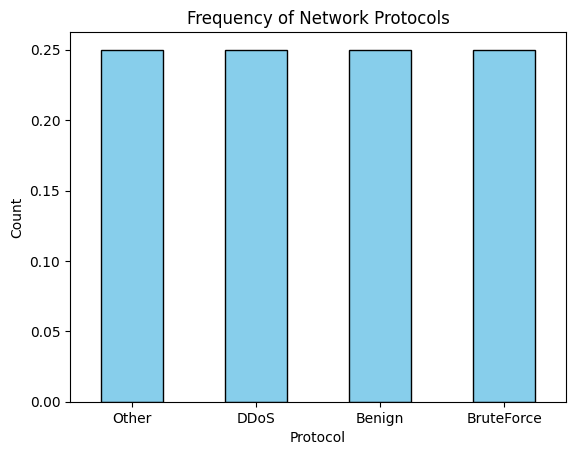

In [13]:
values_count = work_df['Label'].value_counts(normalize=True)
print(values_count)
values_count.plot(
    kind='bar', 
    title='Frequency of Network Protocols',
    xlabel='Protocol',
    ylabel='Count',
    color='skyblue',
    edgecolor='black'
)

# 3. Show the plot
plt.xticks(rotation=0) # Keeps the labels horizontal
plt.show()

In [14]:
work_df['Flow Duration'].plot(
    kind='hist',
    bins=5000, # Número de "fatias" do gráfico
    title='Distribuição da Duração do Fluxo',
    color='steelblue',
    edgecolor='black'
)

plt.show()

TypeError: no numeric data to plot

## KNN

In [ ]:
features = ['Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts']
target = 'Label'


work_df = df[features + [target]].copy()

work_df.loc[(work_df[target] == 'DDOS attack-LOIC-UDP') |
            (work_df[target] == 'DoS attacks-Slowloris') |
            (work_df[target] == 'DoS attacks-GoldenEye') |
            (work_df[target] == 'DoS attacks-SlowHTTPTest') |
            (work_df[target] == 'DoS attacks-Hulk') |
            (work_df[target] == 'DDoS attacks-LOIC-HTTP') |
            (work_df[target] == 'DDOS attack-HOIC'), target] = 'DDoS'

work_df.loc[(work_df[target] == 'Brute Force -XSS') |
            (work_df[target] == 'Brute Force -Web') | 
            (work_df[target] == 'SSH-Bruteforce') | 
            (work_df[target] == 'FTP-BruteForce'), target] = 'BruteForce'

work_df.loc[(work_df[target] == 'Bot') |
            (work_df[target] == 'Infilteration') | 
            (work_df[target] == 'SQL Injection'), target] = 'Other'

possible_labels = work_df[target].unique()

min_class_size = work_df[target].value_counts().min()
print( work_df[target].value_counts())

work_df = work_df.groupby(target).sample(n=min_class_size, random_state=RANDOM_SEED)
work_df = work_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

print(work_df[target].value_counts())

for col in features:
    work_df[col] = pd.to_numeric(work_df[col], errors='coerce')

work_df[features] = work_df[features].fillna(0)

# Função para agrupar as portas pela classificação oficial da IANA
def categorizar_porta(porta):
    if porta <= 1023:
        return 'System_Port'    # Portas conhecidas (80, 443, 22)
    elif porta <= 49151:
        return 'User_Port'      # Portas registradas
    else:
        return 'Dynamic_Port'   # Portas efêmeras/dinâmicas

# 1. Aplica a categorização
work_df['Port_Category'] = work_df['Dst Port'].apply(categorizar_porta)

# 2. Deleta a coluna de porta original (que tem números de 0 a 65535)
work_df = work_df.drop('Dst Port', axis=1)

# 3. Agora sim, faz o One-Hot Encoding seguro
work_df = pd.get_dummies(work_df, columns=['Protocol', 'Port_Category'], dtype=int)

features = [col for col in work_df.columns if col != target]

features_min = work_df[features].min()
features_max = work_df[features].max()

work_df_norm = work_df.copy()

diff = features_max - features_min
diff = diff.replace(0, 1)

work_df_norm[features] = (work_df[features] - features_min) / diff

knowledge_df = work_df_norm.sample(frac=0.995, random_state=RANDOM_SEED)
raw_test_df = work_df_norm.drop(knowledge_df.index)

X_test = raw_test_df[features].values
y_test = raw_test_df[target].values

X_train = knowledge_df[features].values
y_train = knowledge_df[target].values

K = 5 
model_predictions = []

for i in tqdm(range(len(X_test)), desc="Analisando pacotes de rede"):
    test_row = X_test[i]
    
    distances = np.linalg.norm(X_train - test_row, axis=1)
    
    nearest_neighbor_indices = np.argsort(distances)[:K]
    
    k_nearest_labels = y_train[nearest_neighbor_indices]
    
    most_common_label = Counter(k_nearest_labels).most_common(1)[0][0]
    
    model_predictions.append(most_common_label)

results_df = pd.DataFrame({
    'Model_Prediction': model_predictions,
    'Actual_Label': y_test
})

print(f'\nTotal de pacotes testados: {len(results_df)}')
avaliar_modelo(results_df['Actual_Label'].tolist(), results_df['Model_Prediction'].tolist(), f"K-Nearest Neighbors (K={K})")

Label
Benign        2684084
DDoS           384576
Other           89413
BruteForce      76608
Name: count, dtype: int64
Label
Other         76608
DDoS          76608
Benign        76608
BruteForce    76608
Name: count, dtype: int64


Analisando pacotes de rede: 100%|██████████| 1532/1532 [00:31<00:00, 48.67it/s]


Total de pacotes testados: 1532

🔹 AVALIAÇÃO DE DESEMPENHO: K-Nearest Neighbors (K=5)
Acurácia:       89.6214%
Precisão:       89.6695%
Revocação:      89.5933%
Especificidade: 96.5493%
F1-Score:       89.5176%
-----------------------------------------------------------------
MATRIZ DE CONFUSÃO:
                  Prev: Benign  Prev: BruteForce  Prev: DDoS  Prev: Other
Real: Benign               325                 0          12           34
Real: BruteForce             1               361           8            0
Real: DDoS                   7                20         383            0
Real: Other                 68                 1           8          304



## Árvore de Decisão


In [ ]:
class TreeNode:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature       
        self.threshold = threshold   
        self.left = left             
        self.right = right           
        self.value = value           

def calculate_entropy(y):
    n_samples = len(y)
    if n_samples == 0: 
        return 0
    
    class_counts = Counter(y)
    entropy = 0.0
    
    for cls in class_counts:
        probability = class_counts[cls] / n_samples
        if probability > 0: 
            entropy -= probability * np.log2(probability)
            
    return entropy

class DecisionTree:
    def __init__(self, max_depth=3):
        self.max_depth = max_depth
        self.root = None

    def fit(self, X, y):
        self.root = self._build_tree(X, y, depth=0)

    def _build_tree(self, X, y, depth):
        n_samples, n_features = X.shape
        n_classes = len(np.unique(y))
        
        if (depth >= self.max_depth) or (n_classes == 1) or (n_samples < 2):
            most_common_label = Counter(y).most_common(1)[0][0]
            return TreeNode(value=most_common_label)
            
        best_feature, best_threshold = self._find_best_split(X, y, n_features)

        if best_feature is None:
            most_common_label = Counter(y).most_common(1)[0][0]
            return TreeNode(value=most_common_label)
            
        left_idxs = np.where(X[:, best_feature] <= best_threshold)[0]
        right_idxs = np.where(X[:, best_feature] > best_threshold)[0]
        
        left_branch = self._build_tree(X[left_idxs, :], y[left_idxs], depth + 1)
        right_branch = self._build_tree(X[right_idxs, :], y[right_idxs], depth + 1)
        
        return TreeNode(feature=best_feature, threshold=best_threshold, left=left_branch, right=right_branch)

    def _find_best_split(self, X, y, n_features):
        best_info_gain = -1
        best_feature = None
        best_threshold = None
        current_entropy = calculate_entropy(y)
        
        for feature_idx in range(n_features):
            feature_values = X[:, feature_idx]
            
            unique_values = np.unique(feature_values)
            if len(unique_values) > 10:
                thresholds = np.percentile(feature_values, np.linspace(10, 90, 9))
            else:
                thresholds = unique_values

            for threshold in thresholds:
                left_idxs = np.where(feature_values <= threshold)[0]
                right_idxs = np.where(feature_values > threshold)[0]

                if len(left_idxs) == 0 or len(right_idxs) == 0: 
                    continue

                n = len(y)
                n_left, n_right = len(left_idxs), len(right_idxs)
                
                entropy_left = calculate_entropy(y[left_idxs])
                entropy_right = calculate_entropy(y[right_idxs])
                
                weighted_entropy = (n_left / n) * entropy_left + (n_right / n) * entropy_right
                info_gain = current_entropy - weighted_entropy

                if info_gain > best_info_gain:
                    best_info_gain = info_gain
                    best_feature = feature_idx
                    best_threshold = threshold

        return best_feature, best_threshold

    def predict(self, X):
        return [self._traverse_tree(x, self.root) for x in X]

    def _traverse_tree(self, x, node):
        if node.value is not None:
            return node.value
        
        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        else:
            return self._traverse_tree(x, node.right)

tree = DecisionTree(max_depth=4) 
tree.fit(X_train, y_train)

tree = DecisionTree(max_depth=4) 
tree.fit(X_train, y_train)

model_predictions = tree.predict(X_test)

results_df = pd.DataFrame({
    'Model_Prediction': model_predictions,
    'Actual_Label': y_test
})

print(f'\nTotal de pacotes testados: {len(results_df)}')
avaliar_modelo(results_df['Actual_Label'].tolist(), results_df['Model_Prediction'].tolist(), f"Árvore de Decisão (Profundidade={tree.max_depth})")


Total de pacotes testados: 1532

🔹 AVALIAÇÃO DE DESEMPENHO: Árvore de Decisão (Profundidade=4)
Acurácia:       85.9661%
Precisão:       86.9560%
Revocação:      85.8544%
Especificidade: 95.3004%
F1-Score:       85.7724%
-----------------------------------------------------------------
MATRIZ DE CONFUSÃO:
                  Prev: Benign  Prev: BruteForce  Prev: DDoS  Prev: Other
Real: Benign               285                 5          76            5
Real: BruteForce             1               369           0            0
Real: DDoS                   0                25         385            0
Real: Other                 84                 2          17          278

